# Downloading Sentinel2 data from Copernicus Data Space Ecosystem

`farmingpy` allows downloading Sentinel 2 data from CDSE https://dataspace.copernicus.eu/ and calculating biophysical indices

In [ ]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from farmingpy import eo
import configparser

Can't find CLR. Reading TimeLogData not available


# Download data for one parcel from CDSE

<Axes: >

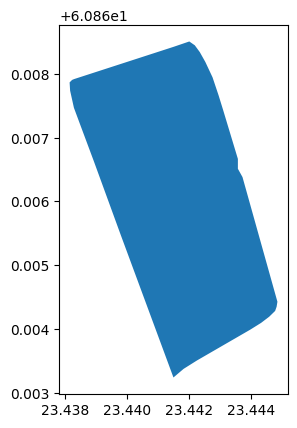

In [3]:
parcel = gpd.read_parquet("data/parcel_N6.parquet")
parcel.plot()

In [ ]:
# Download Sentinel2 data from CDSE as dataset for one growing season
# Read S3 access keys from configuration file

s3cfg = configparser.ConfigParser()
s3cfg.read(Path.home() / ".s3cfg")
s3cfg["cdse"]["access_key"]

s2 = eo.S2CDSE(parcel, access_key=s3cfg["cdse"]["access_key"], secret_key=s3cfg["cdse"]["access_token"])
s2.get_data("2025-05-01", "2025-08-30")

## Calculate biophysical variables

Based on: Weiss, M., Baret, F., Jay, S., 2020. S2ToolBox level 2 products LAI, FAPAR, FCOVER. EMMAH-CAPTE, INRAe Avignon. http://step.esa.int/docs/extra/ATBD_S2ToolBox_V2.0.pdf

and https://github.com/senbox-org/s2tbx/tree/master/s2tbx-biophysical 

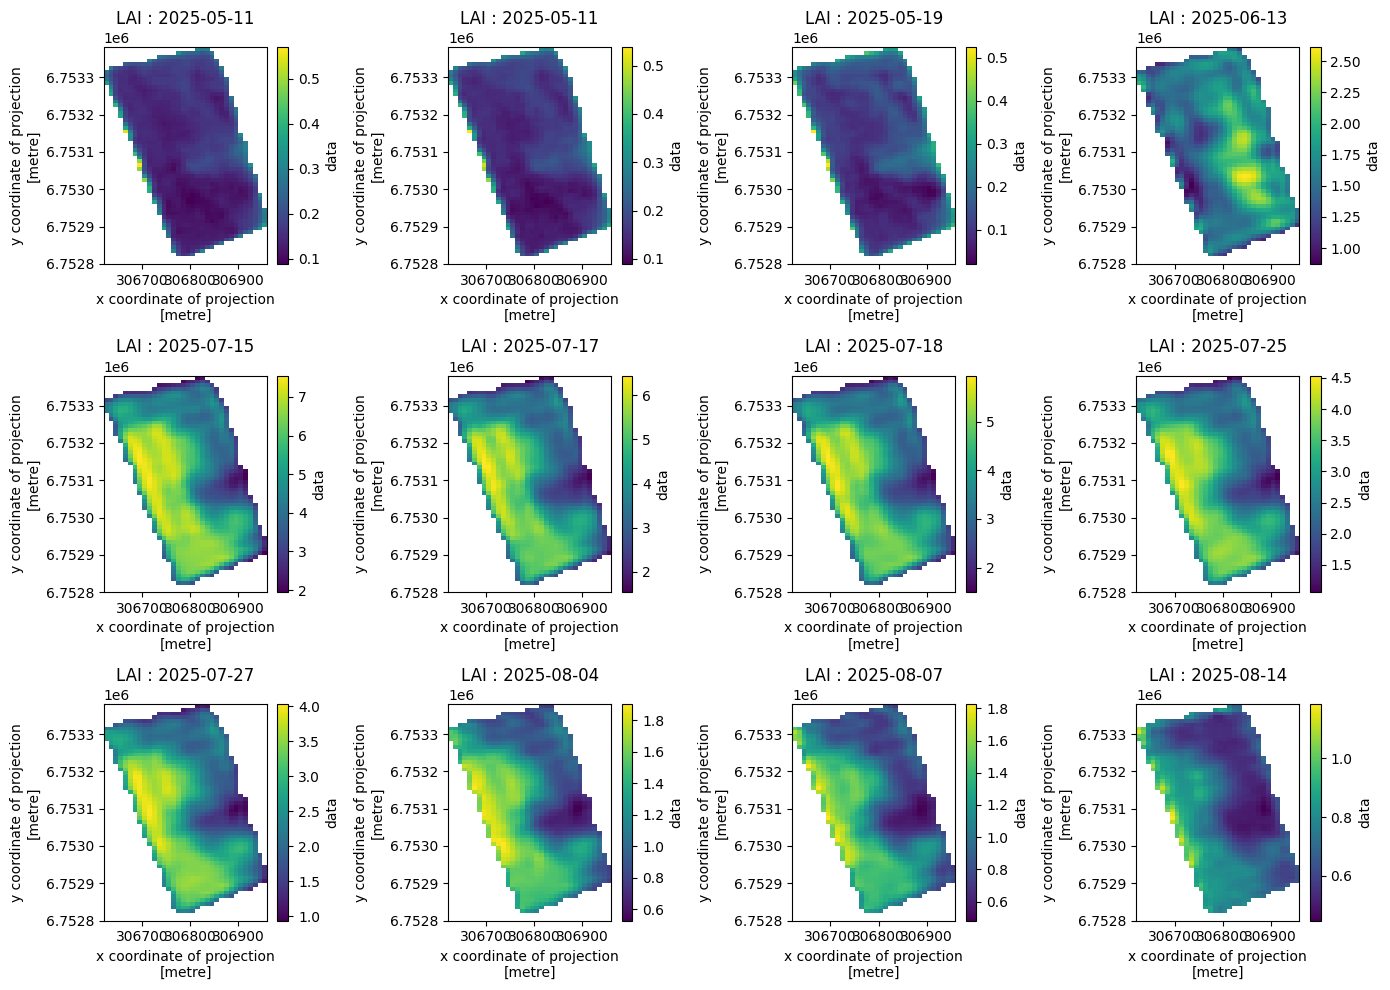

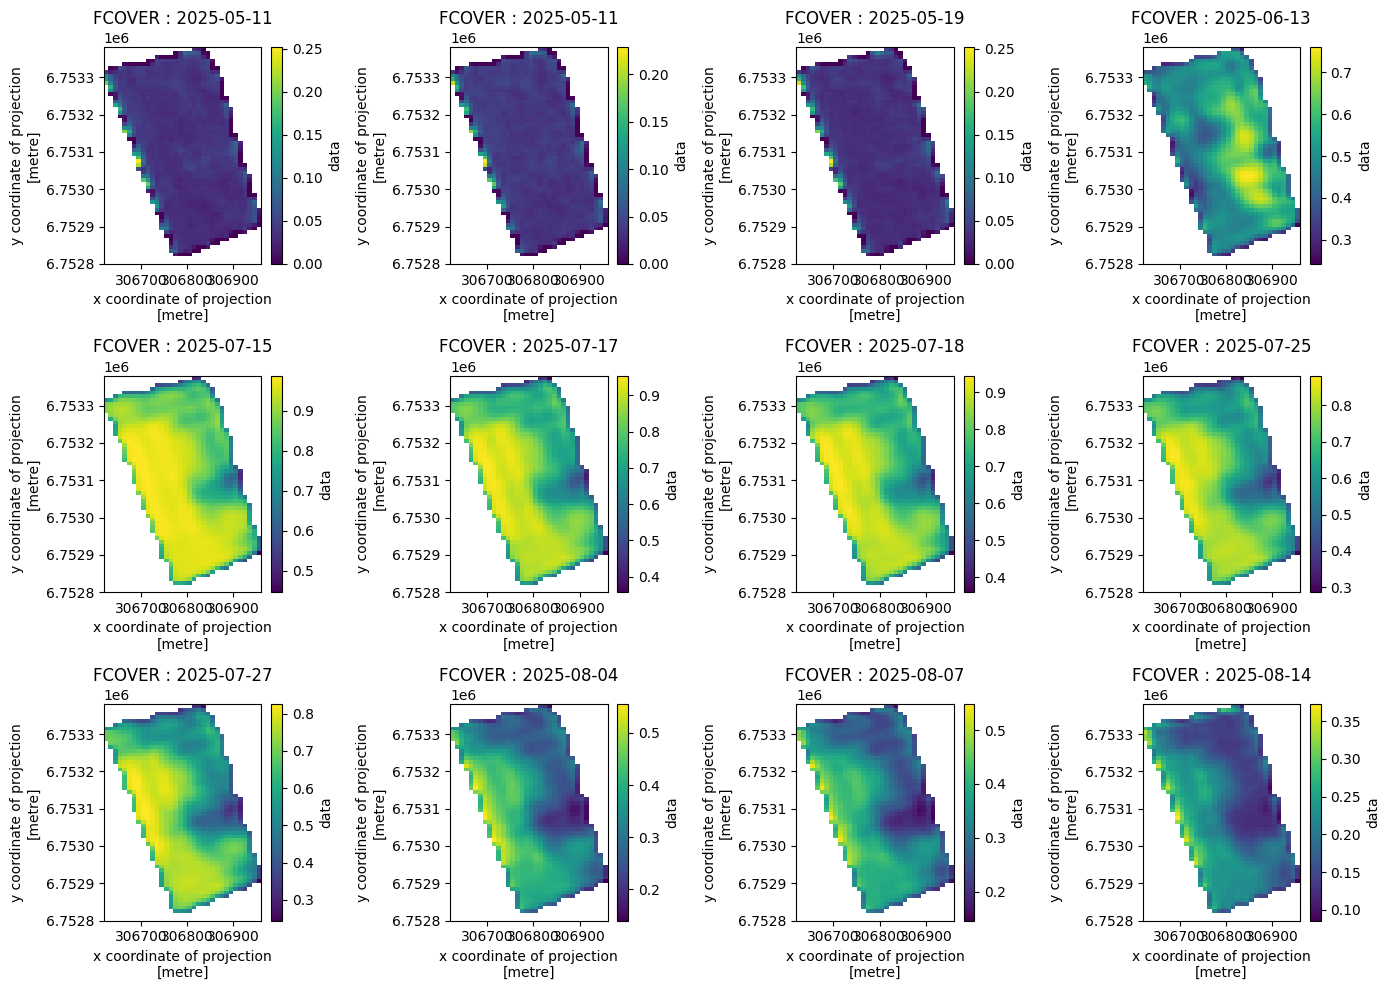

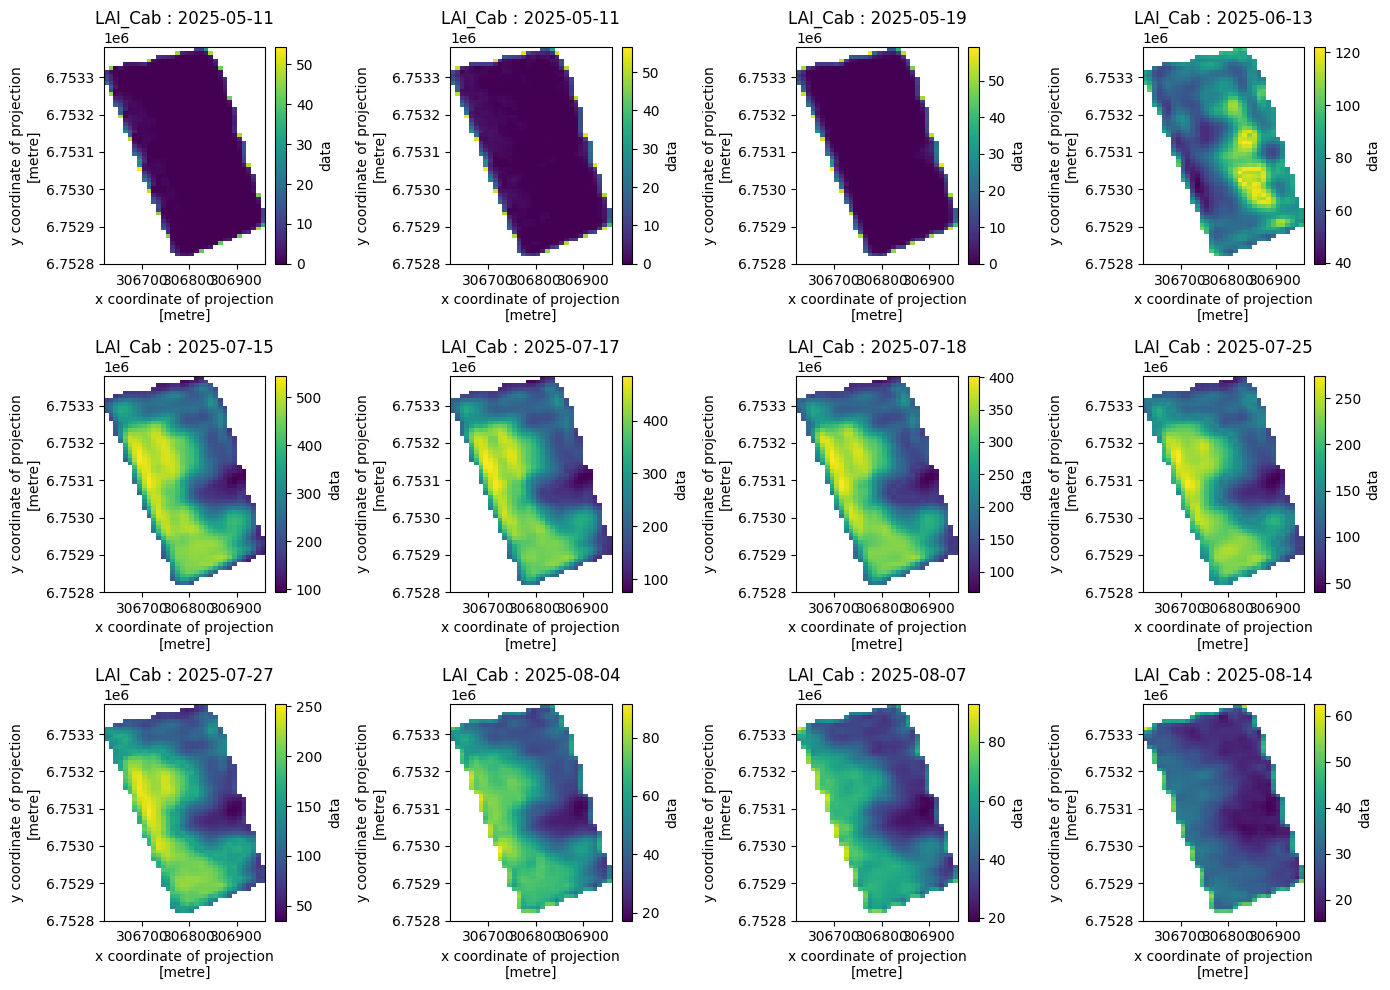

In [89]:
import matplotlib.pyplot as plt

for par in ["LAI", "FCOVER", "LAI_Cab"]:
    biopar = eo.BioPhysS2tbx(par)
    par_ds = s2.data.groupby("time").apply(biopar)

    cols = 4
    fig, ax = plt.subplots(len(par_ds)//cols, cols, layout="tight", figsize=(14,10))
    ax = ax.flatten()
    for i in range(len(par_ds.time)-1):
        p = par_ds.isel(time=i)
        p.plot(ax=ax[i])
        ax[i].set_title(f"{par} : {p.time.values}".split('T')[0])
        